In [2]:
import sys
import glob
import argparse
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import textwrap

sns.set_theme(style="whitegrid")


def wrap_labels(ax, width, break_long_words=False):
    labels = []
    for label in ax.get_xticklabels():
        text = label.get_text()
        labels.append(textwrap.fill(text, width=width,
                      break_long_words=break_long_words))
    ax.set_xticklabels(labels, rotation=0)




In [3]:

def read_data(csv_file_base, ratios, samples):
    output = []

    for r in ratios:
        for s in range(samples):
             # Read the remaining data from CSV into a DataFrame
            csv_file_path = csv_file_base.replace("replace-me-r", str(r)).replace("replace-me-s", str(s+1))
            df = pd.read_csv(csv_file_path, skiprows=0)
            #df = df[['Accuracy', 'Scope']]
            df = df.drop(['Rank', 'src_feature', 'dst_feature'], axis=1)
            # df = df[df['Scope'] == "VPN-all"]
        
            # Melt the DataFrame to long format
            df_melted = pd.melt(df,
                                id_vars='Scope',
                                var_name='Metric',
                                value_name='Value')
            df_melted['Splits'] = r
            df_melted['Value'] = df_melted['Value'] * 100
            
            output.append(df_melted)
    return pd.concat(output)

ratios = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
samples = 20
file_base = "../config_multiscope/podns_multi_scale5k10k_base_replace-me-r_replace-me-s.yamlbest.csv"
out = read_data(file_base, ratios, samples)
out

,Scope,Metric,Value,Splits
0,Service-all,Accuracy,100.000000,10
1,resolver-all,Accuracy,92.857143,10
2,ISP1-all,Accuracy,11.224490,10
3,global,Accuracy,100.000000,10
4,Service-all,Recall@1,100.000000,10
...,...,...,...,...
51,global,F-beta@8,22.222222,100
52,Service-all,MRR,100.000000,100
53,resolver-all,MRR,34.779711,100
54,ISP1-all,MRR,15.703221,100


In [4]:
def parse_name(file_path):
    import os.path
    base = os.path.basename(file_path)
    PPTs = base.split('_multi')[0]
    return PPTs.upper().replace('_', ' & ')
    
plot_name = parse_name(file_base)
plot_name

'PODNS'

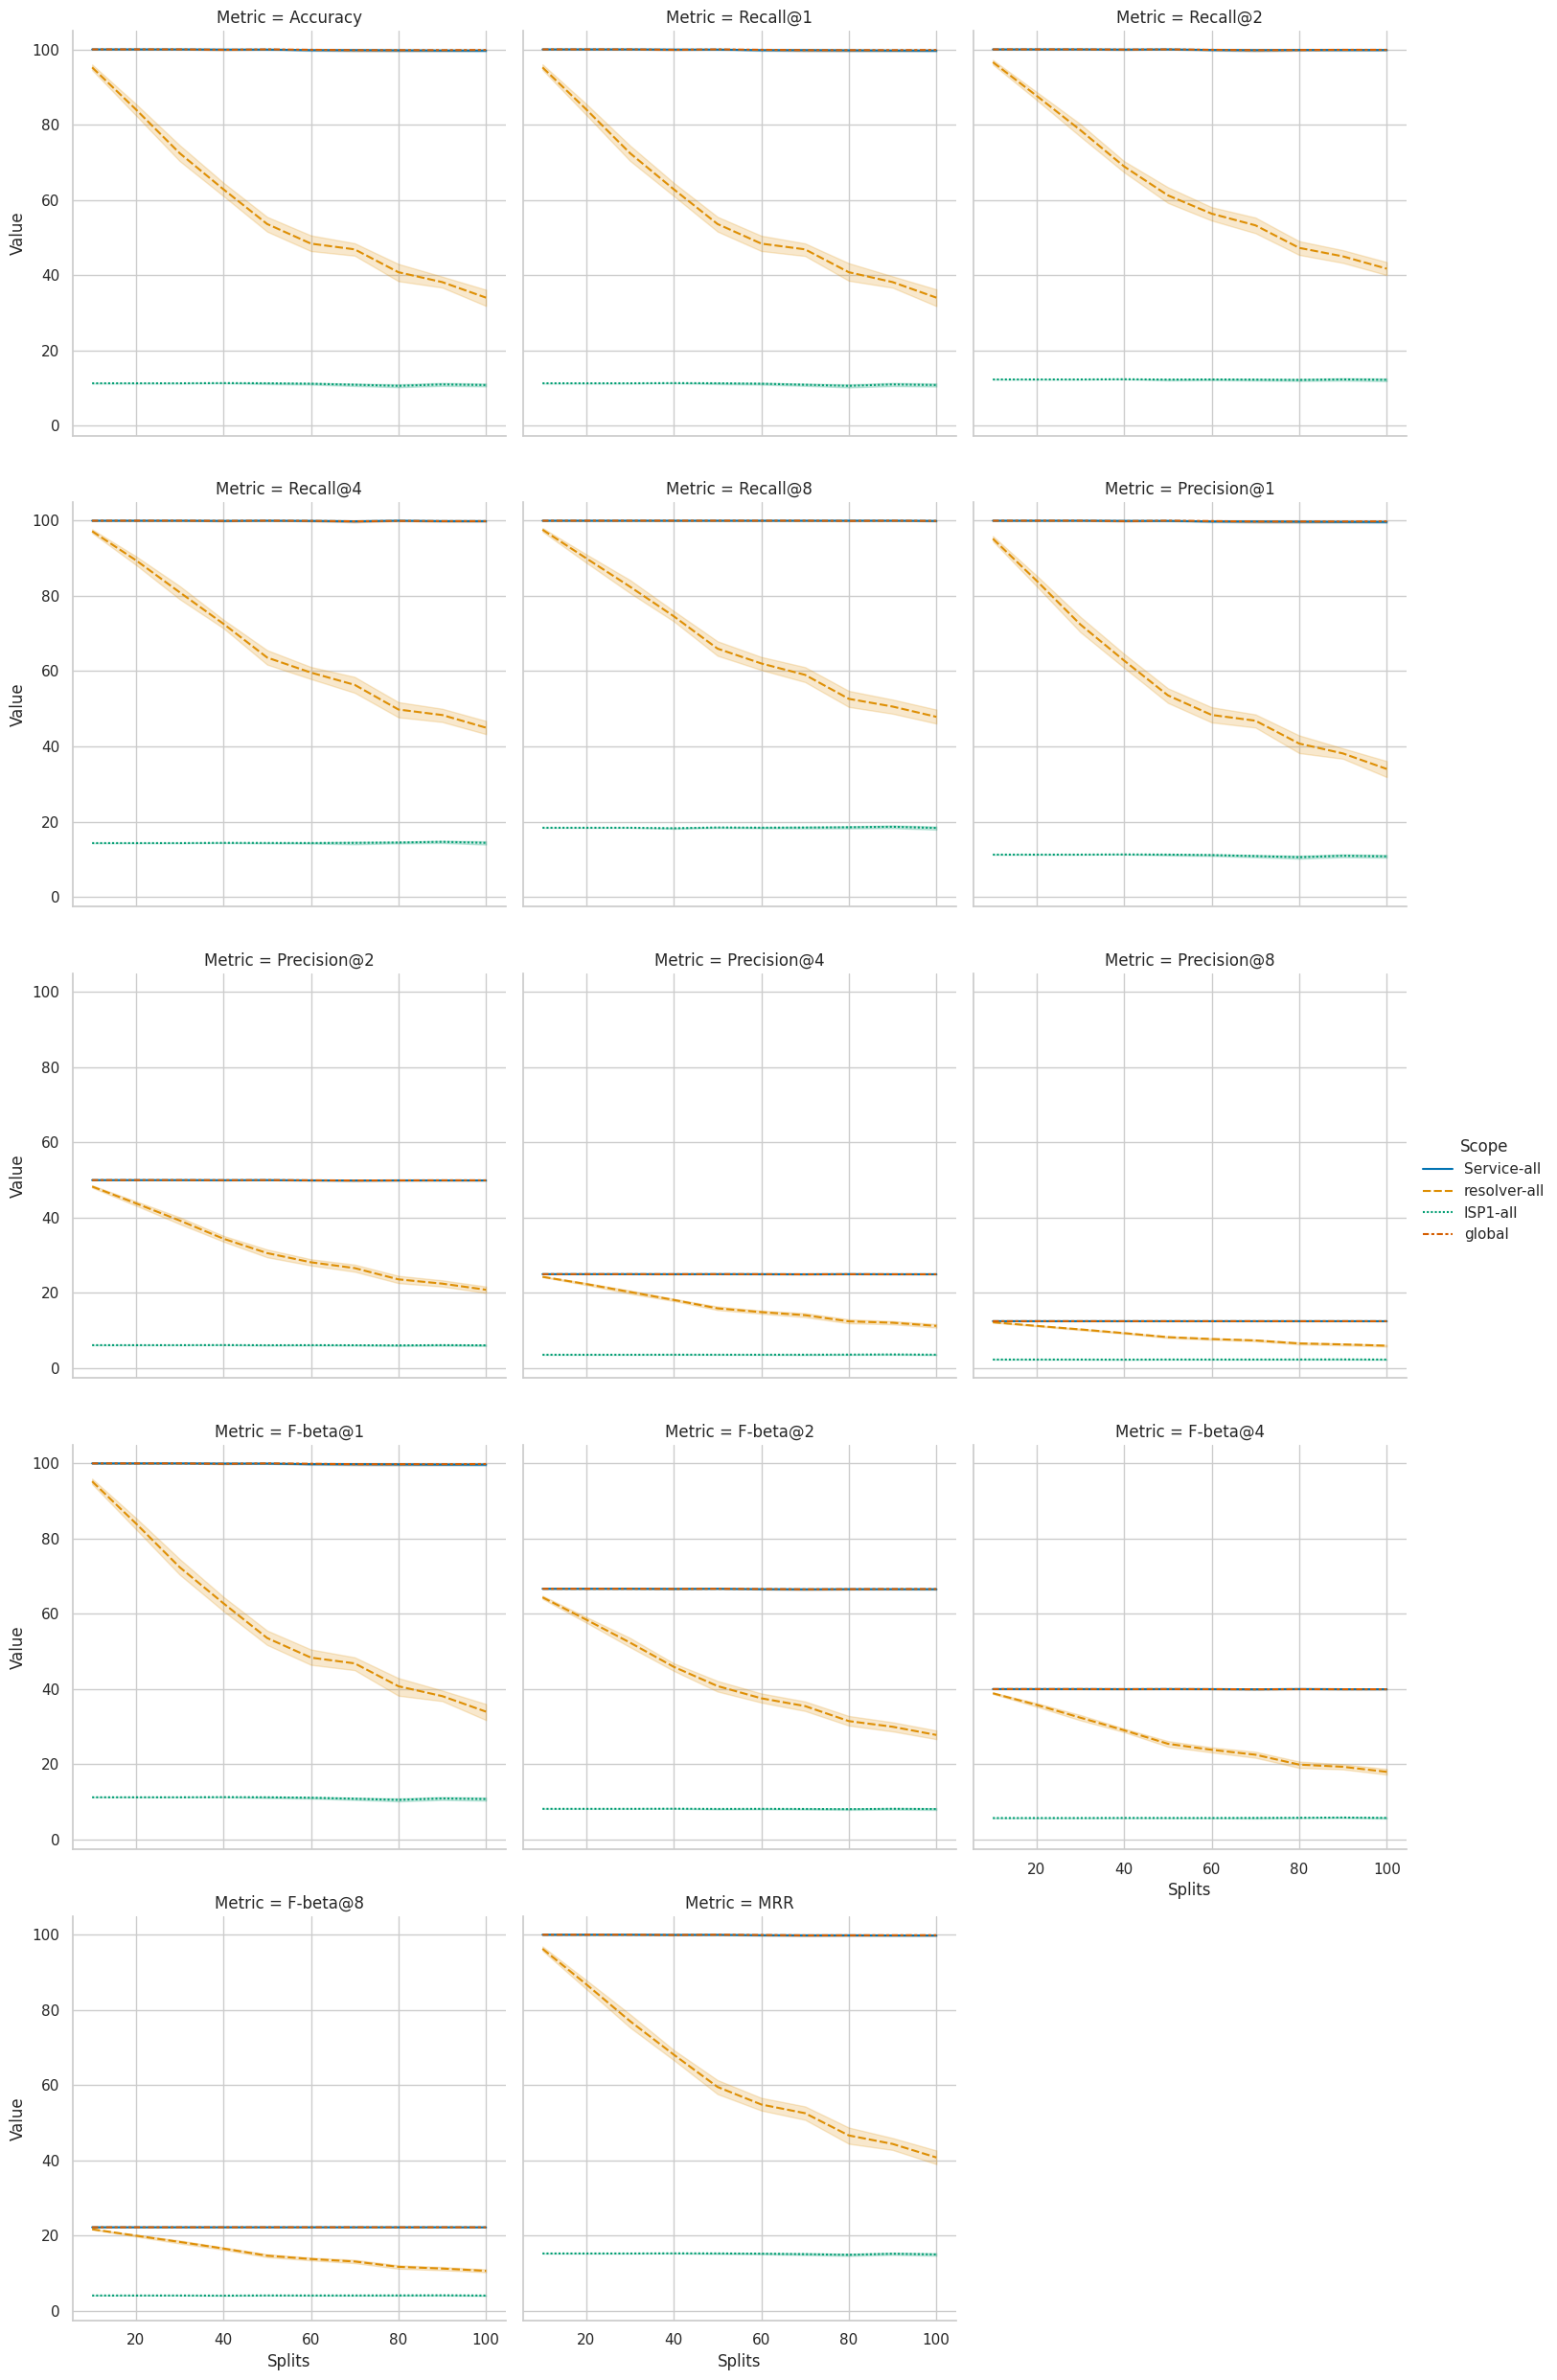

In [5]:
sns.relplot(
    data=out, x="Splits", y="Value",
    col="Metric", hue="Scope", style="Scope",
    kind="line", col_wrap=3, palette="colorblind"
)
plt.savefig("{} Variable Egresses All Metrics.pdf".format(plot_name))

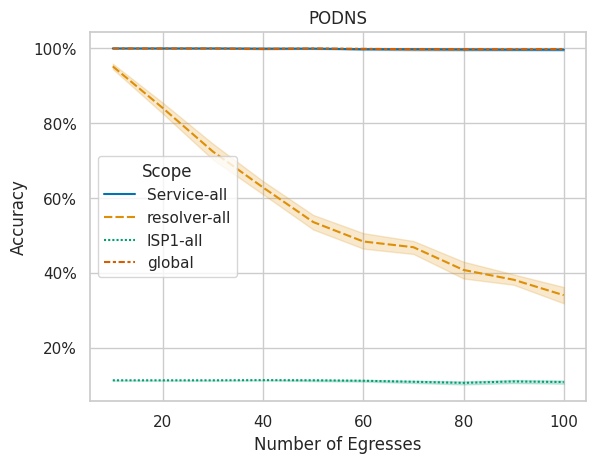

In [7]:
o2 = out#[out['Scope'] != 'ISP1-all']
metric = 'Accuracy'
ax = sns.lineplot(data=o2[o2['Metric'] == metric], x="Splits", y="Value", hue="Scope", style="Scope", palette="colorblind")
ax.set(title=plot_name, xlabel='Number of Egresses', ylabel=metric)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
plt.savefig("{} Variable Egresses.pdf".format(plot_name))

In [16]:
def make_chart(csv_file_path):
    title_line = parse_name(csv_file_path) + " 3 Routes"

    # Read the remaining data from CSV into a DataFrame
    df = pd.read_csv(csv_file_path, skiprows=0)

    df = df[['Accuracy', 'Scope', 'Recall@2', 'Recall@4', 'Recall@8']]

    # Melt the DataFrame to long format
    df_melted = pd.melt(df,
                        id_vars='Scope',
                        var_name='Metric',
                        value_name='Value')

    # Draw a grouped barplot
    g = sns.catplot(
        data=df_melted, kind="bar",
        x="Metric", y="Value", hue="Scope",
        errorbar=None, palette="colorblind", alpha=0.7, height=6#, legend_out=True
    )

    g.despine(left=True)
    g.set_axis_labels("", "")
    sns.move_legend(g, loc='lower center', bbox_to_anchor=(.5, 0), ncol=5, frameon=False,)
    g.legend.set_title("Metric")

    g.fig.suptitle(title_line)

    plt.tight_layout()
    plt.subplots_adjust(bottom=0.2)

    # Wrap text labels
    ax = plt.gca()
    wrap_labels(ax, 10)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

    # Save the plot as a PDF file
    plt.savefig("{}.pdf".format(title_line))

    plt.show()

/tmp/ipykernel_10507/2743187330.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels, rotation=0)


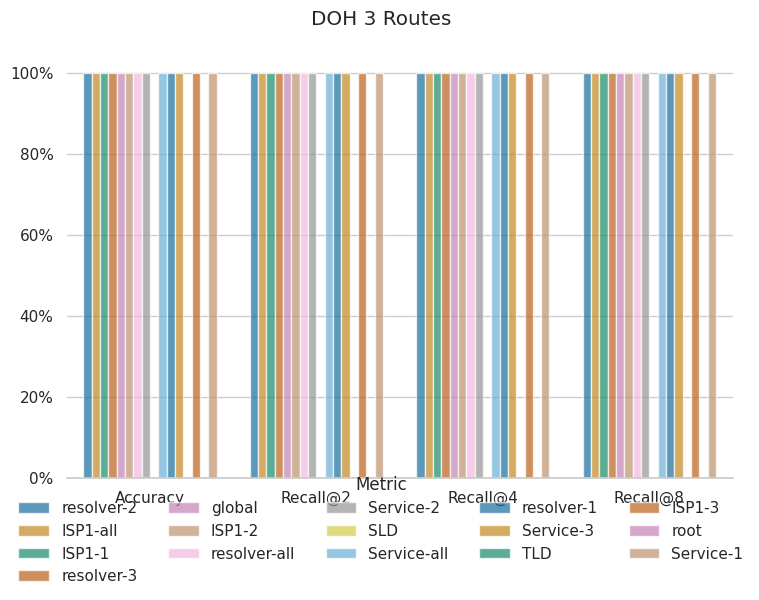

In [21]:
file = "../config_multiscope/doh_multi_scale5k10k.yamlbest.csv"
make_chart(file)